# 00b - Shared OCR Pipeline Build and Validation\n
This notebook validates the reusable OCR infrastructure in `src/ocr_engine.py`.\n
\n
It demonstrates:\n
- cache-aware OCR execution\n
- word/line/block structured outputs\n
- diagnostics image output\n
- downstream loaders for text, layout, and invoice extraction use-cases

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import load_ocr_config
from src.ocr_engine import (
    check_tesseract_installation,
    ocr_batch,
    ocr_document,
    load_ocr_result,
    load_ocr_text,
    load_ocr_words,
    load_ocr_lines,
    load_ocr_blocks,
)

## 1) Load OCR Configuration

In [2]:
cfg = load_ocr_config(PROJECT_ROOT / 'configs' / 'config.yaml')
cfg

OCRConfig(tesseract_cmd=None, lang='eng', psm=6, oem=3, extra_config='', preprocess_mode='adaptive', enable_grayscale=True, enable_denoise=True, enable_deskew=False, resize_max_dim=1800, min_confidence=0.0, diagnostics_enabled=True, cache_dir='data/interim/ocr', diagnostics_dir='outputs/ocr_diagnostics', failure_log_path='data/interim/ocr/logs/ocr_failures.jsonl')

## 2) Tesseract Installation Check

In [3]:
tesseract_ok = check_tesseract_installation(cfg.tesseract_cmd, verbose=True)
tesseract_ok

2026-03-30 18:15:21,088 | INFO | ocr_engine | Tesseract available: 5.5.2 | path=/opt/homebrew/bin/tesseract


True

If `False`, install Tesseract and rerun this notebook:\n
- macOS: `brew install tesseract`\n
- Ubuntu/Debian: `sudo apt-get install -y tesseract-ocr`\n
- Windows: install and add to PATH

## 3) Load Example Documents

In [4]:
meta_path = PROJECT_ROOT / 'data' / 'processed' / 'test.csv'
meta = pd.read_csv(meta_path)
sample = (meta.groupby('class_name', group_keys=False).head(1).head(5)).copy()
sample = sample[['doc_id', 'file_path', 'split', 'class_name']].reset_index(drop=True)
sample

,doc_id,file_path,split,class_name
0,doc_00000005,/Users/sofiiaavetisian/Desktop/UNI/statistical...,test,form
1,doc_00007504,/Users/sofiiaavetisian/Desktop/UNI/statistical...,test,resume
2,doc_00032506,/Users/sofiiaavetisian/Desktop/UNI/statistical...,test,email
3,doc_00035043,/Users/sofiiaavetisian/Desktop/UNI/statistical...,test,invoice
4,doc_00037493,/Users/sofiiaavetisian/Desktop/UNI/statistical...,test,budget


## 4) Run Batch OCR (Cache-Aware)

In [5]:
if not tesseract_ok:
    raise RuntimeError('Tesseract is required for OCR execution.')

benchmark = ocr_batch(sample, cfg=cfg, force=False, save_diagnostics=True, show_progress=True)
benchmark

OCR batch: 100%|██████████| 5/5 [00:03<00:00,  1.55it/s]


,doc_id,file_path,split,class_name,status,error,runtime_sec,num_words,avg_conf,cache_hit
0,doc_00000005,/Users/sofiiaavetisian/Desktop/UNI/statistical...,test,form,ok,None,0.502824,35,72.240487,False
1,doc_00007504,/Users/sofiiaavetisian/Desktop/UNI/statistical...,test,resume,ok,None,0.842862,214,87.283666,False
2,doc_00032506,/Users/sofiiaavetisian/Desktop/UNI/statistical...,test,email,ok,None,0.674620,234,57.757972,False
3,doc_00035043,/Users/sofiiaavetisian/Desktop/UNI/statistical...,test,invoice,ok,None,0.398970,64,27.785079,False
4,doc_00037493,/Users/sofiiaavetisian/Desktop/UNI/statistical...,test,budget,ok,None,0.806128,188,39.323515,False


## 5) Benchmark Table

In [6]:
benchmark_view = benchmark[['doc_id', 'runtime_sec', 'num_words', 'avg_conf', 'cache_hit', 'status']]
benchmark_view

,doc_id,runtime_sec,num_words,avg_conf,cache_hit,status
0,doc_00000005,0.502824,35,72.240487,False,ok
1,doc_00007504,0.842862,214,87.283666,False,ok
2,doc_00032506,0.674620,234,57.757972,False,ok
3,doc_00035043,0.398970,64,27.785079,False,ok
4,doc_00037493,0.806128,188,39.323515,False,ok


## 6) Inspect Canonical OCR Output

In [7]:
doc_id = sample.iloc[0]['doc_id']
result = load_ocr_result(doc_id, cfg=cfg)
{
    'doc_id': result['doc_id'],
    'num_words': result['stats']['num_words'],
    'num_lines': result['stats']['num_lines'],
    'avg_word_conf': result['stats']['avg_word_conf'],
    'cache_hit': result['cache_hit'],
}

{'doc_id': 'doc_00000005',
 'num_words': 35,
 'num_lines': 15,
 'avg_word_conf': 72.24048671428572,
 'cache_hit': False}

## 7) Downstream Consumer Helpers

In [8]:
# A) Text-classification usage\n
text = load_ocr_text(doc_id, cfg=cfg)
print(text[:800])

DISTRIBUTION LISTS: TOX100
po
Lists Last Updated: March 10, 2000
PO
Hardcopy Distribution List
‘SOP Issued To: Document Number:
‘TOX100.004,022900.01
Dwayne Hedrick TOX100.004.022900.02
TOX100.004.022900.03
Sheri Bowman, 3 lab copies
TOX 100.004.022900.05,
TOX100.004.022900.06
2
3
5


In [9]:
# B) Layout-feature usage\n
words_df = load_ocr_words(doc_id, cfg=cfg)
lines_df = load_ocr_lines(doc_id, cfg=cfg)
display(words_df.head())
display(lines_df.head())

,word_id,text,conf,left,top,width,height,right,bottom,page_num,block_num,par_num,line_num,norm_left,norm_top,norm_width,norm_height
0,0,DISTRIBUTION,96.702057,132,122,95,12,227,134,1,1,1,1,0.175066,0.122,0.125995,0.012
1,1,LISTS:,91.295685,232,122,42,11,274,133,1,1,1,1,0.307692,0.122,0.055703,0.011
2,2,TOX100,72.933662,451,122,50,11,501,133,1,1,1,1,0.598143,0.122,0.066313,0.011
3,3,po,0.000000,87,137,540,18,627,155,1,1,1,2,0.115385,0.137,0.716180,0.018
4,4,Lists,96.862320,140,159,31,11,171,170,1,1,1,3,0.185676,0.159,0.041114,0.011


,line_id,text,left,top,width,height,right,bottom,page_num,block_num,par_num,line_num,word_ids
0,0,DISTRIBUTION LISTS: TOX100,132,122,369,12,501,134,1,1,1,1,"[0, 1, 2]"
1,1,po,87,137,540,18,627,155,1,1,1,2,[3]
2,2,"Lists Last Updated: March 10, 2000",140,158,384,13,524,171,1,1,1,3,"[4, 5, 6, 7, 8, 9]"
3,3,PO,83,169,100,30,183,199,1,1,1,4,[10]
4,4,Hardcopy Distribution List,271,194,172,12,443,206,1,1,1,5,"[11, 12, 13]"


In [10]:
# C) Invoice-extraction usage\n
blocks_df = load_ocr_blocks(doc_id, cfg=cfg)
display(blocks_df.head())

,block_id,text,left,top,width,height,right,bottom,page_num,block_num
0,0,DISTRIBUTION LISTS: TOX100\npo\nLists Last Upd...,83,122,586,790,669,912,1,1


## 8) Diagnostics Visualization

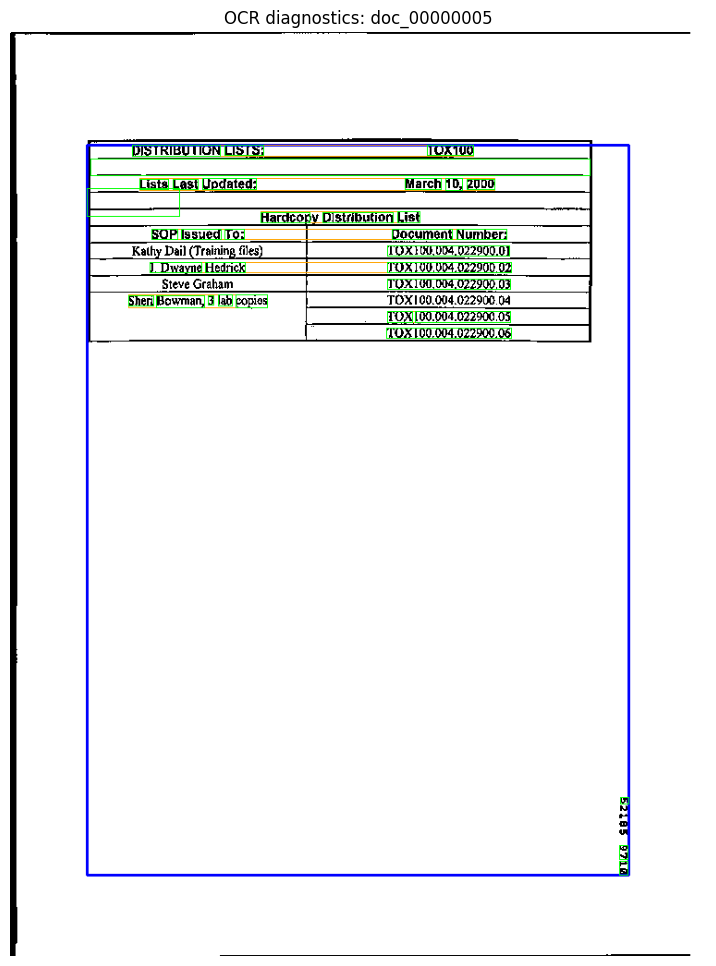

In [11]:
diag_path = PROJECT_ROOT / cfg.diagnostics_dir / f'{doc_id}.png'
if diag_path.exists():
    img = plt.imread(diag_path)
    plt.figure(figsize=(10, 12))
    plt.imshow(img)
    plt.title(f'OCR diagnostics: {doc_id}')
    plt.axis('off')
else:
    print('Diagnostics image not found:', diag_path)

## 9) Verify Cache Files

In [12]:
cache_root = PROJECT_ROOT / cfg.cache_dir
print('raw :', cache_root / 'raw' / f'{doc_id}.csv')
print('json:', cache_root / 'parsed' / f'{doc_id}.json')
print('text:', cache_root / 'text' / f'{doc_id}.txt')

raw : /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/data/interim/ocr/raw/doc_00000005.csv
json: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/data/interim/ocr/parsed/doc_00000005.json
text: /Users/sofiiaavetisian/Desktop/UNI/statistical_learning/FINAL_PROJECT/document-classification/data/interim/ocr/text/doc_00000005.txt
